<a href="https://colab.research.google.com/github/mishra2arya/Unsuppervised-learning/blob/main/k_means_on_iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Cluster assignments:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4              

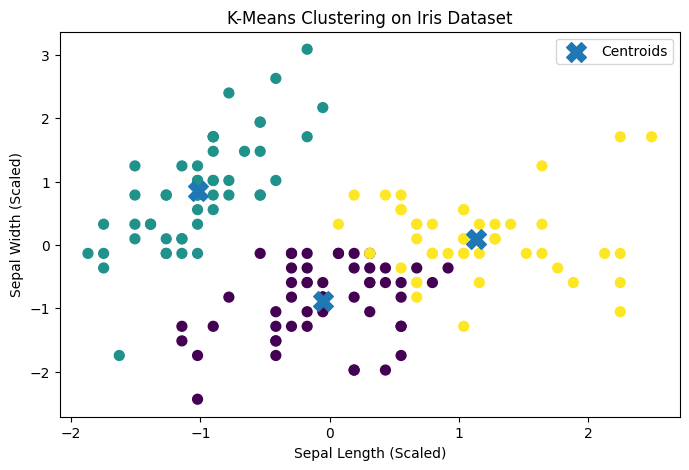

In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Convert to DataFrame
df = pd.DataFrame(X, columns=iris.feature_names)

print("First 5 rows:")
print(df.head())

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create K-Means model
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Fit the model
kmeans.fit(X_scaled)

# Get cluster labels
clusters = kmeans.labels_

# Add cluster labels to DataFrame
df["Cluster"] = clusters

print("\nCluster assignments:")
print(df.head(10))

# Calculate silhouette score
score = silhouette_score(X_scaled, clusters)

print("\nSilhouette Score:", score)

# Plot clusters using first two features
plt.figure(figsize=(8, 5))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters,
    s=50
)

# Plot centroids
centroids = kmeans.cluster_centers_

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=200,
    label="Centroids"
)

plt.xlabel("Sepal Length (Scaled)")
plt.ylabel("Sepal Width (Scaled)")
plt.title("K-Means Clustering on Iris Dataset")
plt.legend()

plt.show()